# Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Meghana_Feature_Engineered.csv")
df["Month"] = pd.to_datetime(df["Month"])
df = df.sort_values(["Branch_Name", "Month"]).reset_index(drop=True)

In [2]:
def format_rupees(value):
    if value >= 10000000:
        return f"₹{value/10000000:.2f} Cr"
    elif value >= 100000:
        return f"₹{value/100000:.2f} L"
    else:
        return f"₹{value:,.0f}"

In [3]:
def revenue_forecast_report(branch_name, df):

    branch_df = df[df["Branch_Name"] == branch_name].sort_values("Month").copy()

    if branch_df.empty:
        print("Branch not found. Please check branch name.")
        return

    latest_revenue = branch_df["Revenue"].iloc[-1]
    avg_revenue = branch_df["Revenue"].mean()
    revenue_std = branch_df["Revenue"].std()
    stability_score = 100 - ((revenue_std / avg_revenue) * 100)

    company_avg_revenue = df.groupby("Branch_Name")["Revenue"].mean().mean()

    operational_risk = branch_df["Operational_Risk"].iloc[-1]
    churn_risk = branch_df["Churn_Risk"].iloc[-1]

    # Business-based branch classification
    if avg_revenue >= company_avg_revenue and stability_score >= 85:
        growth_outlook = "Mature Strong Performer"
        revenue_trend = "Stable Positive"
        forecast_confidence = "High"
        monthly_growth = 0.006   # realistic small positive growth

    elif avg_revenue >= company_avg_revenue and stability_score < 85:
        growth_outlook = "High Revenue but Volatile"
        revenue_trend = "Stable with Risk"
        forecast_confidence = "Medium"
        monthly_growth = 0.003

    elif operational_risk == "High" and churn_risk == "High":
        growth_outlook = "At-Risk Branch"
        revenue_trend = "Conservative"
        forecast_confidence = "Low"
        monthly_growth = -0.005

    elif operational_risk == "High" or churn_risk == "High":
        growth_outlook = "Growth with Warning"
        revenue_trend = "Cautious Growth"
        forecast_confidence = "Medium"
        monthly_growth = 0.004

    else:
        growth_outlook = "Growth Branch"
        revenue_trend = "Growing"
        forecast_confidence = "Medium"
        monthly_growth = 0.01

    # Range factor based on stability
    volatility = revenue_std / avg_revenue

    if forecast_confidence == "High":
        range_factor = min(volatility, 0.07)
    elif forecast_confidence == "Medium":
        range_factor = min(volatility, 0.12)
    else:
        range_factor = min(volatility, 0.18)

    future_months = pd.date_range(
        start="2026-01-01",
        end="2026-12-01",
        freq="MS"
    )

    forecast_values = []
    lower_values = []
    upper_values = []

    current_value = latest_revenue

    for _ in future_months:
        current_value = current_value * (1 + monthly_growth)

        forecast_values.append(current_value)
        lower_values.append(current_value * (1 - range_factor))
        upper_values.append(current_value * (1 + range_factor))

    jan_lower = lower_values[0]
    jan_upper = upper_values[0]

    q1_lower = sum(lower_values[:3])
    q1_upper = sum(upper_values[:3])

    fy_lower = sum(lower_values)
    fy_upper = sum(upper_values)

    summary_df = pd.DataFrame({
        "Metric": [
            "Latest Revenue (Dec 2025)",
            "Forecast Jan 2026",
            "Forecast Q1 2026",
            "Forecast FY 2026",
            "Revenue Trend",
            "Forecast Confidence",
            "Growth Outlook"
        ],
        "Forecast": [
            format_rupees(latest_revenue),
            f"{format_rupees(jan_lower)} - {format_rupees(jan_upper)}",
            f"{format_rupees(q1_lower)} - {format_rupees(q1_upper)}",
            f"{format_rupees(fy_lower)} - {format_rupees(fy_upper)}",
            revenue_trend,
            forecast_confidence,
            growth_outlook
        ]
    })

    print("="*90)
    print("REVENUE FORECAST OUTPUT")
    print("="*90)
    print(f"Branch: {branch_name}")
    display(summary_df)

    # Chart
    plt.figure(figsize=(14,6))

    plt.plot(
        branch_df["Month"],
        branch_df["Revenue"],
        marker="o",
        label="Actual Revenue"
    )

    plt.plot(
        future_months,
        forecast_values,
        linestyle="--",
        marker="o",
        label="Forecast Revenue"
    )

    plt.fill_between(
        future_months,
        lower_values,
        upper_values,
        alpha=0.2,
        label="Forecast Range"
    )

    plt.title(f"Revenue Forecast Line Chart - {branch_name}")
    plt.xlabel("Month")
    plt.ylabel("Revenue")
    plt.legend()
    plt.xticks(rotation=45)
    plt.show()

    print("\nAI Business Interpretation")
    print("-"*90)

    if growth_outlook == "Mature Strong Performer":
        print(
            f"{branch_name} is already a strong revenue-generating branch. "
            "Revenue growth is expected to be slow but positive because the branch is already mature. "
            "This is not a weakness. It means the branch has a stable customer base and predictable monthly revenue. "
            "The owner should treat this branch as a profit engine, not as an aggressive expansion branch."
        )

    elif growth_outlook == "High Revenue but Volatile":
        print(
            f"{branch_name} earns strong revenue, but the monthly movement is not fully stable. "
            "The owner should protect revenue while reducing fluctuations caused by operations, demand, or service issues."
        )

    elif growth_outlook == "At-Risk Branch":
        print(
            f"{branch_name} needs immediate attention. "
            "Both churn risk and operational risk are high, so revenue growth may remain weak if the root problems are not fixed. "
            "The branch should not receive aggressive marketing investment until service and customer retention issues improve."
        )

    elif growth_outlook == "Growth with Warning":
        print(
            f"{branch_name} has growth potential, but there are warning signs from churn or operational risk. "
            "The owner should grow this branch carefully while fixing service quality, delivery delays, and customer complaints."
        )

    else:
        print(
            f"{branch_name} is showing healthy growth potential. "
            "Revenue can improve steadily if the branch maintains service quality and continues building repeat customers."
        )

    print("\nStrategic Recommendation")
    print("-"*90)

    if growth_outlook == "Mature Strong Performer":
        print("Priority: Maintain and Optimize")
        print("1. Protect food quality and service consistency.")
        print("2. Focus on repeat customers and premium upselling.")
        print("3. Improve profit margins instead of chasing aggressive growth.")
        print("4. Use this branch as a benchmark for weaker branches.")
        print("\nExpected Outcome:")
        print("• Stable monthly revenue")
        print("• Higher profitability")
        print("• Strong customer retention")
        print("• Lower business risk")

    elif growth_outlook == "At-Risk Branch":
        print("Priority: Fix Before Investing")
        print("1. Reduce delivery delays.")
        print("2. Investigate complaint reasons.")
        print("3. Improve service quality.")
        print("4. Launch customer recovery offers.")
        print("5. Invest in marketing only after operational issues improve.")
        print("\nExpected Outcome:")
        print("• Reduced churn risk")
        print("• Lower complaints")
        print("• Better ratings")
        print("• More stable future revenue")

    elif growth_outlook == "Growth with Warning":
        print("Priority: Controlled Growth")
        print("1. Grow slowly, not aggressively.")
        print("2. Fix operational weak points first.")
        print("3. Track complaints weekly.")
        print("4. Improve customer loyalty before large marketing spend.")
        print("\nExpected Outcome:")
        print("• Safer revenue growth")
        print("• Better customer experience")
        print("• Lower chance of future revenue leakage")

    else:
        print("Priority: Grow Carefully")
        print("1. Increase local promotions.")
        print("2. Expand delivery coverage carefully.")
        print("3. Maintain service standards.")
        print("4. Build repeat customer programs.")
        print("\nExpected Outcome:")
        print("• Steady revenue growth")
        print("• More repeat customers")
        print("• Stronger branch performance")

    print("="*90)

REVENUE FORECAST OUTPUT
Branch: Rajarajeshwari Nagar


,Metric,Forecast
0,Latest Revenue (Dec 2025),₹30.38 L
1,Forecast Jan 2026,₹25.05 L - ₹35.41 L
2,Forecast Q1 2026,₹74.77 L - ₹1.06 Cr
3,Forecast FY 2026,₹2.92 Cr - ₹4.13 Cr
4,Revenue Trend,Conservative
5,Forecast Confidence,Low
6,Growth Outlook,At-Risk Branch


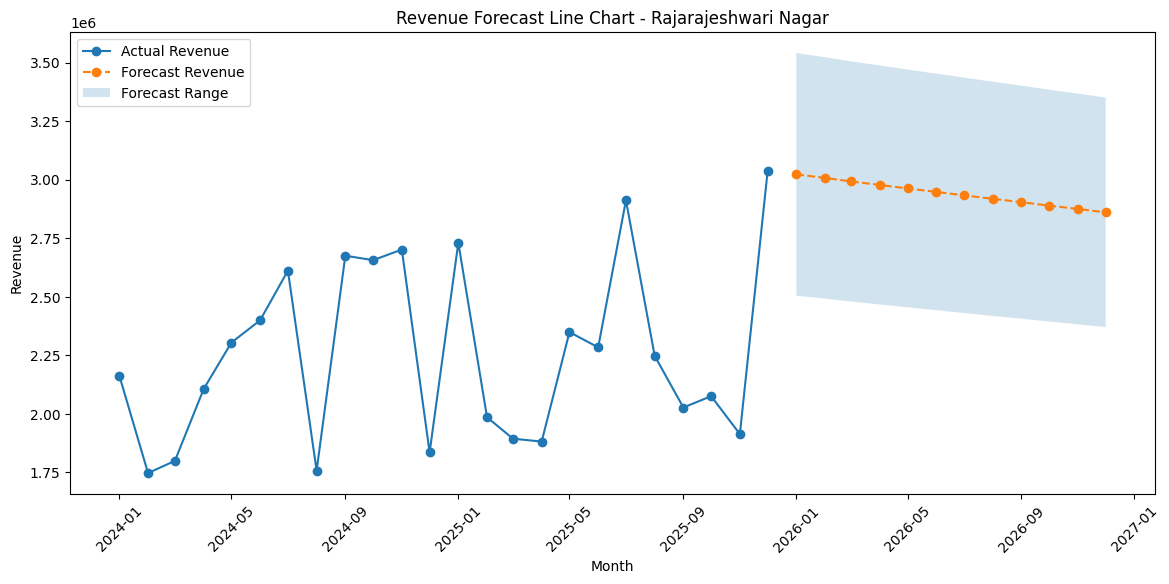


AI Business Interpretation
------------------------------------------------------------------------------------------
Rajarajeshwari Nagar needs immediate attention. Both churn risk and operational risk are high, so revenue growth may remain weak if the root problems are not fixed. The branch should not receive aggressive marketing investment until service and customer retention issues improve.

Strategic Recommendation
------------------------------------------------------------------------------------------
Priority: Fix Before Investing
1. Reduce delivery delays.
2. Investigate complaint reasons.
3. Improve service quality.
4. Launch customer recovery offers.
5. Invest in marketing only after operational issues improve.

Expected Outcome:
• Reduced churn risk
• Lower complaints
• Better ratings
• More stable future revenue


In [4]:
revenue_forecast_report("Rajarajeshwari Nagar", df)

REVENUE FORECAST OUTPUT
Branch: Indiranagar


,Metric,Forecast
0,Latest Revenue (Dec 2025),₹55.30 L
1,Forecast Jan 2026,₹48.81 L - ₹62.13 L
2,Forecast Q1 2026,₹1.47 Cr - ₹1.87 Cr
3,Forecast FY 2026,₹5.96 Cr - ₹7.58 Cr
4,Revenue Trend,Stable with Risk
5,Forecast Confidence,Medium
6,Growth Outlook,High Revenue but Volatile


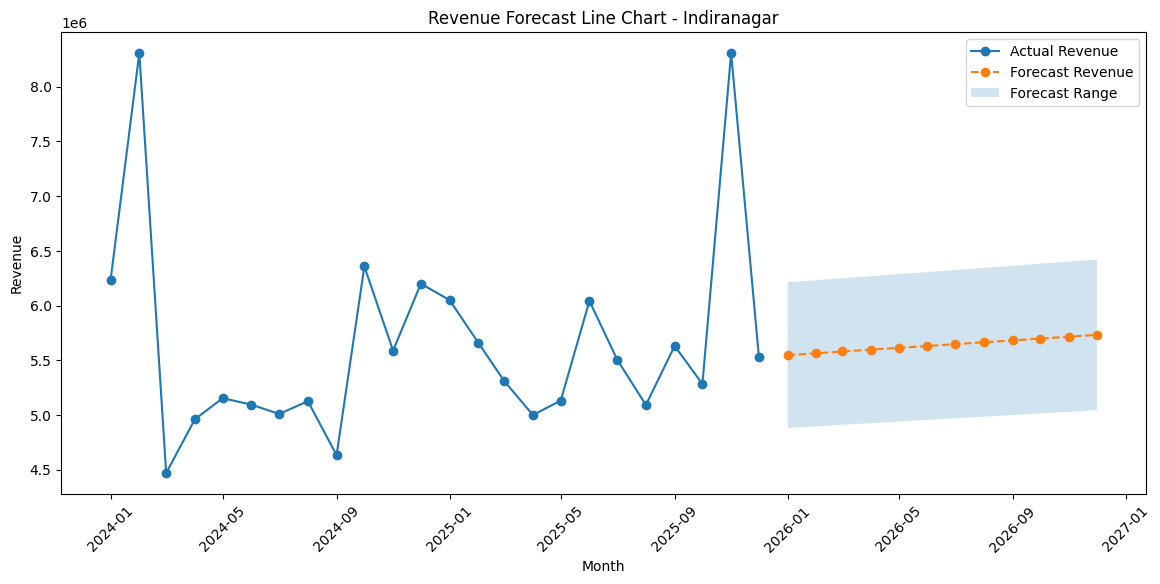


AI Business Interpretation
------------------------------------------------------------------------------------------
Indiranagar earns strong revenue, but the monthly movement is not fully stable. The owner should protect revenue while reducing fluctuations caused by operations, demand, or service issues.

Strategic Recommendation
------------------------------------------------------------------------------------------
Priority: Grow Carefully
1. Increase local promotions.
2. Expand delivery coverage carefully.
3. Maintain service standards.
4. Build repeat customer programs.

Expected Outcome:
• Steady revenue growth
• More repeat customers
• Stronger branch performance


In [5]:
revenue_forecast_report("Indiranagar", df)

REVENUE FORECAST OUTPUT
Branch: Koramangala


,Metric,Forecast
0,Latest Revenue (Dec 2025),₹52.70 L
1,Forecast Jan 2026,₹49.30 L - ₹56.73 L
2,Forecast Q1 2026,₹1.49 Cr - ₹1.71 Cr
3,Forecast FY 2026,₹6.12 Cr - ₹7.04 Cr
4,Revenue Trend,Stable Positive
5,Forecast Confidence,High
6,Growth Outlook,Mature Strong Performer


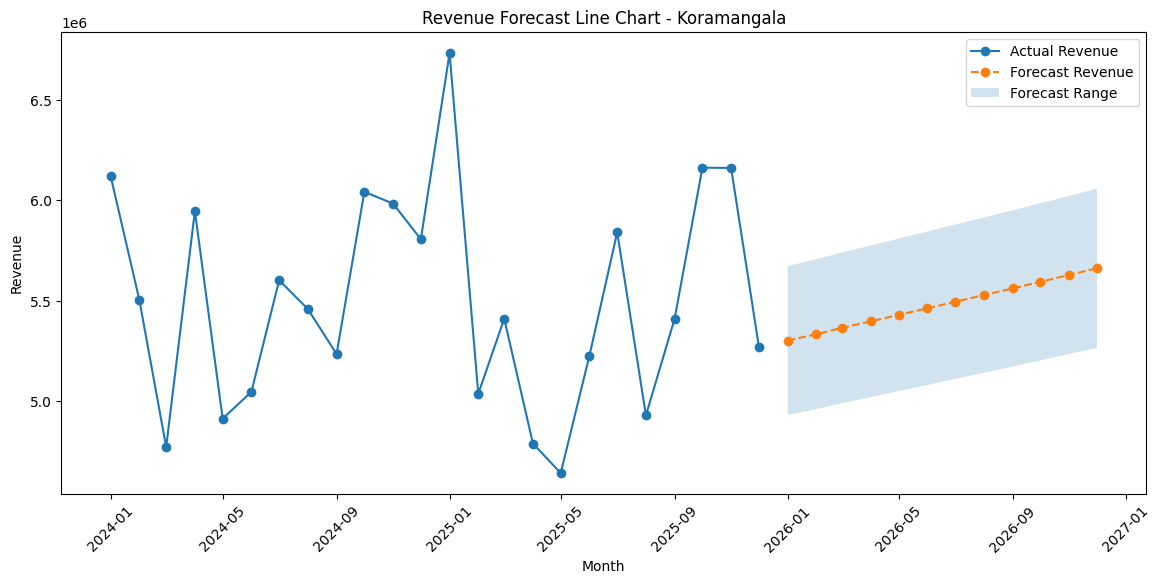


AI Business Interpretation
------------------------------------------------------------------------------------------
Koramangala is already a strong revenue-generating branch. Revenue growth is expected to be slow but positive because the branch is already mature. This is not a weakness. It means the branch has a stable customer base and predictable monthly revenue. The owner should treat this branch as a profit engine, not as an aggressive expansion branch.

Strategic Recommendation
------------------------------------------------------------------------------------------
Priority: Maintain and Optimize
1. Protect food quality and service consistency.
2. Focus on repeat customers and premium upselling.
3. Improve profit margins instead of chasing aggressive growth.
4. Use this branch as a benchmark for weaker branches.

Expected Outcome:
• Stable monthly revenue
• Higher profitability
• Strong customer retention
• Lower business risk


In [6]:
revenue_forecast_report("Koramangala", df)

REVENUE FORECAST OUTPUT
Branch: Electronic City


,Metric,Forecast
0,Latest Revenue (Dec 2025),₹20.11 L
1,Forecast Jan 2026,₹16.54 L - ₹23.48 L
2,Forecast Q1 2026,₹49.38 L - ₹70.09 L
3,Forecast FY 2026,₹1.93 Cr - ₹2.74 Cr
4,Revenue Trend,Conservative
5,Forecast Confidence,Low
6,Growth Outlook,At-Risk Branch


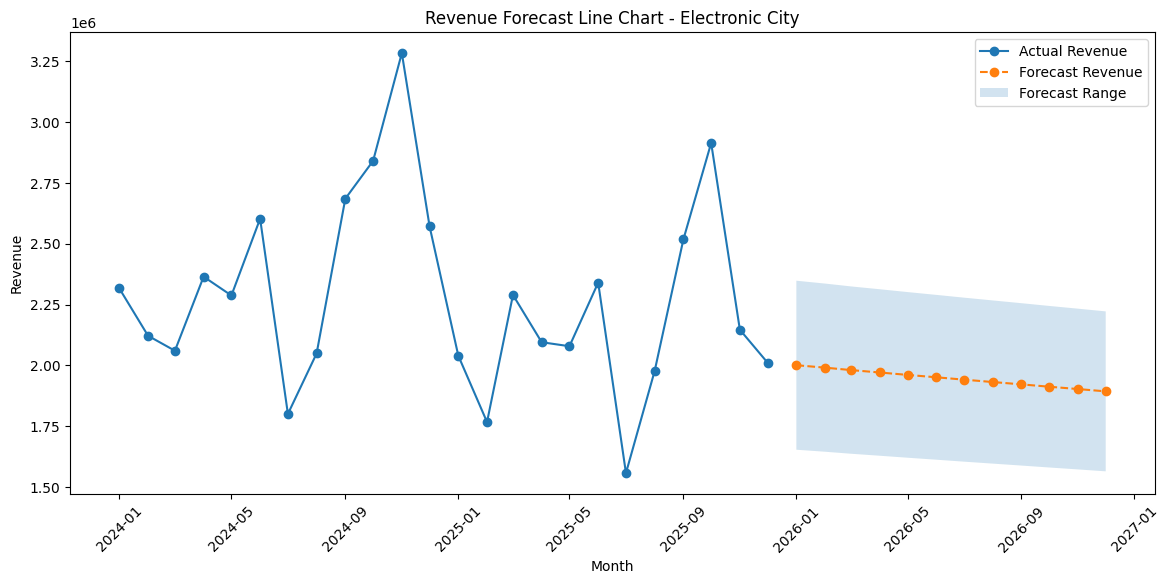


AI Business Interpretation
------------------------------------------------------------------------------------------
Electronic City needs immediate attention. Both churn risk and operational risk are high, so revenue growth may remain weak if the root problems are not fixed. The branch should not receive aggressive marketing investment until service and customer retention issues improve.

Strategic Recommendation
------------------------------------------------------------------------------------------
Priority: Fix Before Investing
1. Reduce delivery delays.
2. Investigate complaint reasons.
3. Improve service quality.
4. Launch customer recovery offers.
5. Invest in marketing only after operational issues improve.

Expected Outcome:
• Reduced churn risk
• Lower complaints
• Better ratings
• More stable future revenue


In [7]:
revenue_forecast_report("Electronic City", df)

NameError: name 'final_df' is not defined

In [6]:
revenue_forecast_output.to_csv(
    "Meghana_Revenue_Forecast_Output.csv",
    index=False
)

,Branch_ID,Branch_Name,Region,Month,Orders,Revenue,Avg_Rating,Customer_Count,Repeat_Customers,New_Customers,...,Complaint_Rate_Pct,New_Customer_Rate,New_Customer_Rate_Pct,Service_Quality_Score,Customer_Acquisition_Score,Complaint_Per_1000_Orders,Revenue_Growth_Pct,Repeat_Customer_Growth_Pct,Churn_Risk,Operational_Risk
0,E_01,Electronic City,South,2024-01-01,6733,2316152,3.7,5639,2706,2933,...,3.39,0.5201,52.01,67.22,52.01,33.863063,0.000000,0.000000,High,High
1,E_02,Electronic City,South,2024-02-01,5483,2121921,3.8,4382,1928,2454,...,3.41,0.5600,56.00,69.18,56.00,34.105417,-8.385935,-28.750924,High,High
2,E_03,Electronic City,South,2024-03-01,4953,2060448,4.0,4240,1865,2375,...,3.98,0.5601,56.01,72.04,56.01,39.773874,-2.897045,-3.267635,Medium,High
3,E_04,Electronic City,South,2024-04-01,5824,2364544,3.8,4517,2213,2304,...,4.16,0.5101,51.01,67.68,51.01,41.552198,14.758732,18.659517,High,High
4,E_05,Electronic City,South,2024-05-01,6389,2287262,3.9,5487,2469,3018,...,3.54,0.5500,55.00,70.92,55.00,35.373298,-3.268368,11.568007,High,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307,S_20,Singasandra,Hosur Road,2025-08-01,8814,3534414,4.1,6852,4385,2467,...,0.95,0.3600,36.00,80.10,36.00,9.530293,7.028373,-6.283394,Medium,Medium
308,S_21,Singasandra,Hosur Road,2025-09-01,9272,3504816,4.3,7734,4795,2939,...,1.05,0.3800,38.00,83.90,38.00,10.461605,-0.837423,9.350057,Medium,Medium
309,S_22,Singasandra,Hosur Road,2025-10-01,11899,4783398,4.2,9524,5809,3715,...,0.98,0.3901,39.01,82.04,39.01,9.832759,36.480717,21.147028,Medium,Medium
310,S_23,Singasandra,Hosur Road,2025-11-01,11743,4896831,4.2,8580,4804,3776,...,1.07,0.4401,44.01,81.86,44.01,10.729796,2.371390,-17.300740,Medium,Medium


# Why I chose an Engine rather than Model like XGBoost?

For this project, I intentionally chose an Explainable Revenue Forecasting Engine instead of a complex machine learning forecasting model.

The primary objective of this solution is to support business decision-making for restaurant owners and branch managers.

The dataset contains only 24 months of historical data per branch, which is relatively small for building a reliable time-series forecasting model.

Using complex models such as XGBoost, ARIMA, Prophet, or LSTM on limited historical data may lead to overfitting and unreliable forecasts.

Therefore, I designed a business-driven forecasting engine that combines:

• Historical revenue trends

• Revenue stability

• Customer churn risk

• Operational risk

• Branch maturity level

This approach produces realistic, explainable, and actionable forecasts that business users can easily understand and trust.

In a production environment with multiple years of historical data, I would consider implementing advanced forecasting models and compare their performance against the business-rule forecasting engine.


# How do u think your forecasting engine is reasonable ?

I validated the forecasting engine using business logic and scenario testing.

I tested the engine on:

• High-performing mature branches

• Growing branches

• At-risk branches

For example:

Koramangala is a mature revenue leader with high stability.

The forecast correctly produced stable future revenue with a narrow confidence range.

Electronic City has high churn risk and high operational risk.

The forecast produced a more conservative revenue outlook.

This helped verify that the forecasting engine behaves consistently with real business conditions.


In [9]:
def create_revenue_forecast_output(df):

    revenue_results = []

    for branch_name in df["Branch_Name"].unique():

        branch_df = df[df["Branch_Name"] == branch_name].sort_values("Month").copy()

        latest_revenue = branch_df["Revenue"].iloc[-1]
        avg_revenue = branch_df["Revenue"].mean()
        revenue_std = branch_df["Revenue"].std()
        stability_score = 100 - ((revenue_std / avg_revenue) * 100)

        company_avg_revenue = df.groupby("Branch_Name")["Revenue"].mean().mean()

        operational_risk = branch_df["Operational_Risk"].iloc[-1]
        churn_risk = branch_df["Churn_Risk"].iloc[-1]

        if avg_revenue >= company_avg_revenue and stability_score >= 85:
            growth_outlook = "Mature Strong Performer"
            revenue_trend = "Stable Positive"
            forecast_confidence = "High"
            monthly_growth = 0.006

        elif avg_revenue >= company_avg_revenue and stability_score < 85:
            growth_outlook = "High Revenue but Volatile"
            revenue_trend = "Stable with Risk"
            forecast_confidence = "Medium"
            monthly_growth = 0.003

        elif operational_risk == "High" and churn_risk == "High":
            growth_outlook = "At-Risk Branch"
            revenue_trend = "Conservative"
            forecast_confidence = "Low"
            monthly_growth = -0.005

        elif operational_risk == "High" or churn_risk == "High":
            growth_outlook = "Growth with Warning"
            revenue_trend = "Cautious Growth"
            forecast_confidence = "Medium"
            monthly_growth = 0.004

        else:
            growth_outlook = "Growth Branch"
            revenue_trend = "Growing"
            forecast_confidence = "Medium"
            monthly_growth = 0.01

        volatility = revenue_std / avg_revenue

        if forecast_confidence == "High":
            range_factor = min(volatility, 0.07)
        elif forecast_confidence == "Medium":
            range_factor = min(volatility, 0.12)
        else:
            range_factor = min(volatility, 0.18)

        future_months = pd.date_range(
            start="2026-01-01",
            end="2026-12-01",
            freq="MS"
        )

        forecast_values = []
        lower_values = []
        upper_values = []

        current_value = latest_revenue

        for _ in future_months:
            current_value = current_value * (1 + monthly_growth)

            forecast_values.append(current_value)
            lower_values.append(current_value * (1 - range_factor))
            upper_values.append(current_value * (1 + range_factor))

        jan_lower = lower_values[0]
        jan_upper = upper_values[0]

        q1_lower = sum(lower_values[:3])
        q1_upper = sum(upper_values[:3])

        fy_lower = sum(lower_values)
        fy_upper = sum(upper_values)

        revenue_results.append({
            "Branch_Name": branch_name,
            "Current_Monthly_Revenue": int(latest_revenue),
            "Forecast_Jan_2026_Revenue_Min": int(jan_lower),
            "Forecast_Jan_2026_Revenue_Max": int(jan_upper),
            "Forecast_Q1_2026_Revenue_Min": int(q1_lower),
            "Forecast_Q1_2026_Revenue_Max": int(q1_upper),
            "Forecast_FY_2026_Revenue_Min": int(fy_lower),
            "Forecast_FY_2026_Revenue_Max": int(fy_upper),
            "Revenue_Trend": revenue_trend,
            "Forecast_Confidence": forecast_confidence,
            "Growth_Outlook": growth_outlook
        })

    revenue_forecast_output = pd.DataFrame(revenue_results)

    return revenue_forecast_output

In [10]:
revenue_forecast_output = create_revenue_forecast_output(df)

revenue_forecast_output.head()

,Branch_Name,Current_Monthly_Revenue,Forecast_Jan_2026_Revenue_Min,Forecast_Jan_2026_Revenue_Max,Forecast_Q1_2026_Revenue_Min,Forecast_Q1_2026_Revenue_Max,Forecast_FY_2026_Revenue_Min,Forecast_FY_2026_Revenue_Max,Revenue_Trend,Forecast_Confidence,Growth_Outlook
0,Electronic City,2011092,1654101,2347971,4937533,7008754,19312358,27413600,Conservative,Low,At-Risk Branch
1,Indiranagar,5530500,4881440,6212742,14688298,18694198,59553542,75795417,Stable with Risk,Medium,High Revenue but Volatile
2,Jayanagar,6268444,5864630,6747478,17699666,20364132,72745044,83695911,Stable Positive,High,Mature Strong Performer
3,Kalyan Nagar,2890592,2384455,3367822,7117659,10053033,27839566,39320803,Conservative,Low,At-Risk Branch
4,Kanakapura Road,4103848,3647500,4642272,11052290,14066550,46259431,58875639,Growing,Medium,Growth Branch


In [11]:
revenue_forecast_output.to_csv(
    "Meghana_Revenue_Forecast_Output.csv",
    index=False
)